# Exploratory Analysis: Query vs Library DEPT Spectra

1. **t-SNE** — chemical space coverage of query (NMRShiftDB2) vs library (COCONUT subset)
2. **Spectral distributions** — ppm values and peak counts for the overlapping structures
3. **NPClassifier** — structural class distribution of the query compounds

In [1]:
import json
import warnings
from concurrent.futures import ThreadPoolExecutor, as_completed
from urllib.parse import quote

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rdkit
import requests
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from tqdm import tqdm

from dept_similarity.constants import (
    CACHE_DIR,
    FIGURE_DIR,
    LIBRARY_PALETTE,
    PROCESSED_DATA_DIR,
)

rdkit.RDLogger.DisableLog("rdApp.*")
warnings.filterwarnings("ignore")
plt.rcParams.update({"font.size": 11, "figure.dpi": 120})

## Load data

In [2]:
lib_df = pd.read_parquet(f"{PROCESSED_DATA_DIR}/library_data.parquet")
val_df = pd.read_parquet(f"{PROCESSED_DATA_DIR}/experimental_validation_set.parquet")

print(f"Library : {len(lib_df):>10,} spectra")
print(
    f"Query   : {len(val_df):>10,} spectra  ({val_df['inchikey14'].nunique():,} unique inchikey-14s)"
)

Library :    455,289 spectra
Query   :        648 spectra  (644 unique inchikey-14s)


---
## Plot 1 — t-SNE: library vs query

In [3]:
FP_RADIUS = 2
FP_NBITS = 2048
LIBRARY_SUBSET_N = 100_000


def smiles_to_fp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(FP_NBITS, dtype=np.uint8)
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=FP_RADIUS, nBits=FP_NBITS)
    arr = np.zeros(FP_NBITS, dtype=np.uint8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr


lib_sub = lib_df.sample(n=LIBRARY_SUBSET_N, random_state=42).reset_index(drop=True)

print("Computing library fingerprints…")
lib_feat = np.vstack([smiles_to_fp(s) for s in lib_sub["smiles"]])
print("Computing query fingerprints…")
val_feat = np.vstack([smiles_to_fp(s) for s in val_df["smiles"]])

all_feat = np.vstack([lib_feat, val_feat])
labels = np.array(["Library"] * len(lib_sub) + ["Query"] * len(val_df))

print(f"Feature matrix: {all_feat.shape}")

Computing library fingerprints…


Computing query fingerprints…


Feature matrix: (100648, 2048)


In [4]:
# PCA first: reduces 2048-dim fingerprints to 50 dims, making t-SNE much faster
pca = PCA(n_components=50, random_state=42)
feat_pca = pca.fit_transform(all_feat)
print(
    f"PCA: {all_feat.shape} → {feat_pca.shape}  "
    f"(explained variance: {pca.explained_variance_ratio_.sum():.1%})"
)

tsne = TSNE(n_components=2, perplexity=50, max_iter=1000, random_state=42, n_jobs=-1)
emb = tsne.fit_transform(feat_pca)
print("t-SNE done")

PCA: (100648, 2048) → (100648, 50)  (explained variance: 36.9%)


t-SNE done


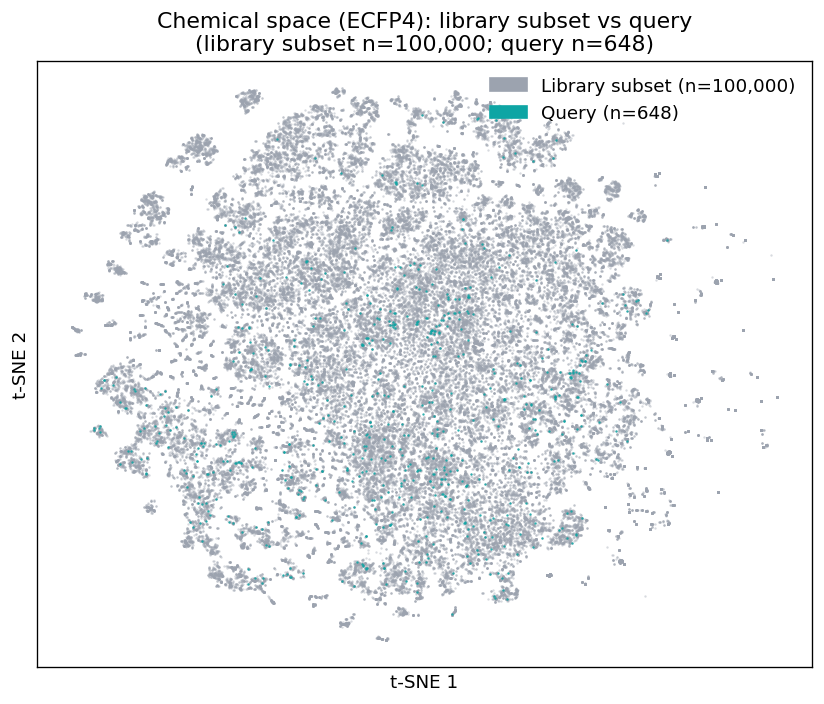

In [5]:
fig, ax = plt.subplots(figsize=(7, 6))

for group, zorder, size, alpha in [("Library", 1, 2, 0.4), ("Query", 2, 2, 0.85)]:
    mask = labels == group
    ax.scatter(
        emb[mask, 0],
        emb[mask, 1],
        c=LIBRARY_PALETTE[group],
        s=size,
        alpha=alpha,
        linewidths=0,
        zorder=zorder,
    )

ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_title(
    "Chemical space (ECFP4): library subset vs query\n"
    f"(library subset n={LIBRARY_SUBSET_N:,}; query n={len(val_df):,})"
)
legend_handles = [
    mpatches.Patch(
        color=LIBRARY_PALETTE["Library"],
        label=f"Library subset (n={LIBRARY_SUBSET_N:,})",
    ),
    mpatches.Patch(color=LIBRARY_PALETTE["Query"], label=f"Query (n={len(val_df):,})"),
]
ax.legend(handles=legend_handles, frameon=False, loc="upper right")
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()


plt.savefig(f"{FIGURE_DIR}/tsne_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

---
## Plot 2 — Spectral distributions for overlapping inchikeys

Each panel compares the library predicted spectrum vs the experimental query spectrum for the **same** structures.

In [6]:
overlap_ik14 = set(val_df["inchikey14"])
lib_overlap = lib_df[lib_df["inchikey14"].isin(overlap_ik14)].copy()

print(f"Library spectra matching overlap inchikeys : {len(lib_overlap):,}")
print(f"Query  spectra matching overlap inchikeys  : {len(val_df):,}")

lib_ppm = [v for row in lib_overlap["signed_shifts"] for v in row]
val_ppm = [v for row in val_df["signed_shifts"] for v in row]
lib_npeaks = lib_overlap["signed_shifts"].apply(len)
val_npeaks = val_df["signed_shifts"].apply(len)

Library spectra matching overlap inchikeys : 644
Query  spectra matching overlap inchikeys  : 648


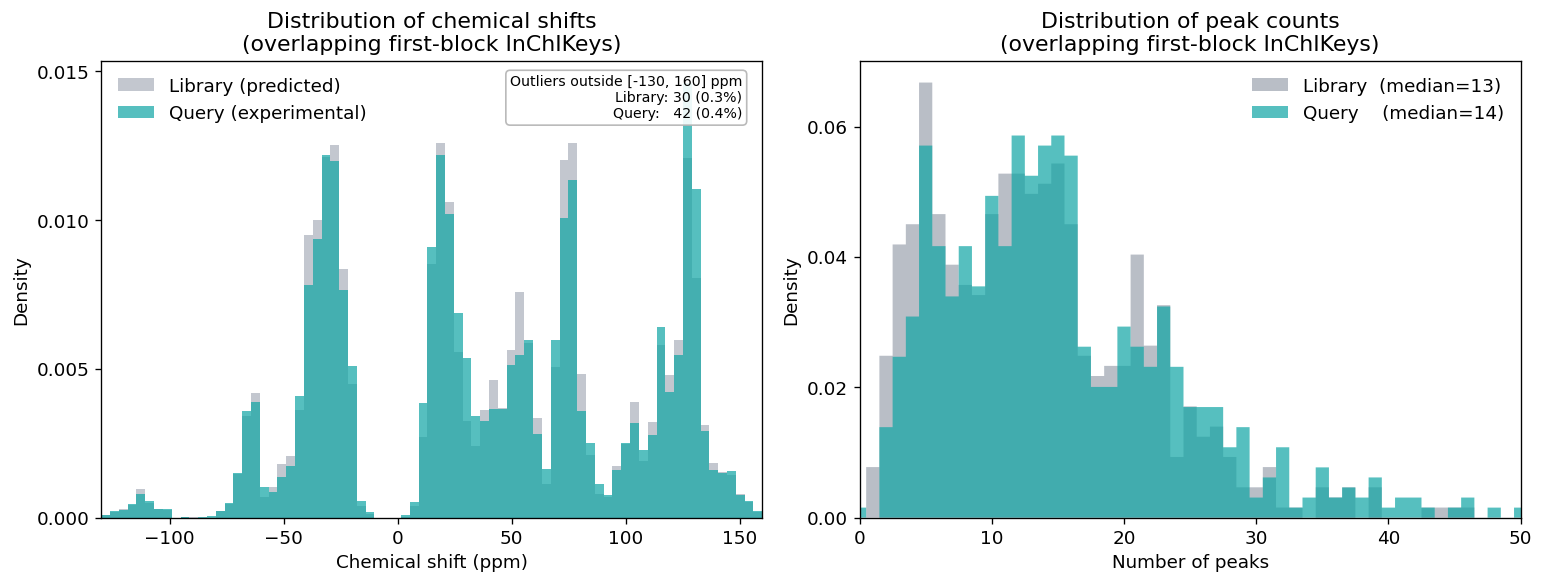

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Subplot 1: ppm distribution ────────────────────────────────────────────
ax = axes[0]

ZOOM_LO, ZOOM_HI = -130, 160
bins_ppm = np.linspace(ZOOM_LO, ZOOM_HI, 76)
kw = dict(bins=bins_ppm, density=True, histtype="stepfilled", edgecolor="none")
ax.hist(
    lib_ppm,
    **kw,
    color=LIBRARY_PALETTE["Library"],
    alpha=0.6,
    label="Library (predicted)",
)
ax.hist(
    val_ppm,
    **kw,
    color=LIBRARY_PALETTE["Query"],
    alpha=0.7,
    label="Query (experimental)",
)

# Annotate outliers outside the zoom window
lib_out = int(((np.array(lib_ppm) < ZOOM_LO) | (np.array(lib_ppm) > ZOOM_HI)).sum())
val_out = int(((np.array(val_ppm) < ZOOM_LO) | (np.array(val_ppm) > ZOOM_HI)).sum())
ax.annotate(
    f"Outliers outside [{ZOOM_LO}, {ZOOM_HI}] ppm\n"
    f"Library: {lib_out} ({lib_out / len(lib_ppm) * 100:.1f}%)\n"
    f"Query:   {val_out} ({val_out / len(val_ppm) * 100:.1f}%)",
    xy=(0.97, 0.97),
    xycoords="axes fraction",
    ha="right",
    va="top",
    fontsize=8.5,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.7", alpha=0.9),
)
ax.set_xlim(ZOOM_LO, ZOOM_HI)
ax.set_xlabel("Chemical shift (ppm)")
ax.set_ylabel("Density")
ax.locator_params(axis="y", nbins=5)
ax.set_title("Distribution of chemical shifts\n(overlapping first-block InChIKeys)")
ax.legend(frameon=False)

# ── Subplot 2: number of peaks ─────────────────────────────────────────────
ax = axes[1]
bins_pk = np.arange(0, 301) - 0.5
kw_pk = dict(bins=bins_pk, density=True, histtype="stepfilled", edgecolor="none", alpha=0.7)
ax.hist(
    lib_npeaks,
    **kw_pk,
    color=LIBRARY_PALETTE["Library"],
    label=f"Library  (median={lib_npeaks.median():.0f})",
)
ax.hist(
    val_npeaks,
    **kw_pk,
    color=LIBRARY_PALETTE["Query"],
    label=f"Query    (median={val_npeaks.median():.0f})",
)
ax.set_xlim(0, 50)
ax.set_xlabel("Number of peaks")
ax.set_ylabel("Density")
ax.locator_params(axis="y", nbins=5)
ax.set_title("Distribution of peak counts\n(overlapping first-block InChIKeys)")
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}/spectra_data_distribution.png", dpi=400, bbox_inches="tight")
plt.show()

---
## Plot 3 — NPClassifier structural classes of query compounds

Calls the [NPClassifier GNPS2 API](https://npclassifier.gnps2.org) for each of the query SMILES.
Results are cached to `../data/processed/npclassifier_cache.json` so subsequent runs are instant.

In [8]:
import os

NPCLASSIFIER_CACHE_PATH = f"{CACHE_DIR}/npclassifier_cache.json"


def fetch_npclassifier(smiles: str, retries: int = 3):
    url = f"https://npclassifier.gnps2.org/classify?smiles={quote(smiles)}"
    for attempt in range(retries):
        try:
            resp = requests.get(url, timeout=30)
            if resp.status_code == 200:
                return resp.json()
        except Exception as e:
            print(f"Attempt {attempt + 1} failed: {e}")
            pass
    return None


# ── Load cache or fetch ────────────────────────────────────────────────────
if os.path.exists(NPCLASSIFIER_CACHE_PATH):
    with open(NPCLASSIFIER_CACHE_PATH) as f:
        npc_cache = json.load(f)  # {inchikey14: result_dict}
    print(f"Loaded {len(npc_cache):,} cached results")
else:
    npc_cache = {}

to_fetch = val_df[~val_df["inchikey14"].isin(npc_cache)].drop_duplicates("inchikey14")
print(f"Need to fetch: {len(to_fetch):,} SMILES")

Loaded 4,771 cached results
Need to fetch: 0 SMILES


In [9]:
if len(to_fetch) > 0:
    with ThreadPoolExecutor(max_workers=8) as pool:
        futures = {
            pool.submit(fetch_npclassifier, row["smiles"]): row["inchikey14"]
            for _, row in to_fetch.iterrows()
        }
        for future in tqdm(as_completed(futures), total=len(futures), desc="NPClassifier"):
            ik14 = futures[future]
            result = future.result()
            if result is not None:
                npc_cache[ik14] = result

    with open(NPCLASSIFIER_CACHE_PATH, "w") as f:
        json.dump(npc_cache, f)
    print(f"Cached {len(npc_cache):,} results → {NPCLASSIFIER_CACHE_PATH}")

In [10]:
# ── Parse pathway + superclass hits (restricted to the current query set) ───
# npc_cache accumulates results across runs (4k+ compounds), so filter to the
# InChIKey-14s actually in val_df — otherwise the distribution reflects the whole
# cache, not the query set.
query_ik14 = set(val_df["inchikey14"])
rows = []
for ik14, result in npc_cache.items():
    if result is None or ik14 not in query_ik14:
        continue
    pathways = result.get("pathway_results") or ["Unclassified"]
    superclasses = result.get("superclass_results") or ["Unclassified"]
    for pathway in pathways:
        for sc in superclasses:
            rows.append({"inchikey14": ik14, "pathway": pathway, "superclass": sc})

npc_df = pd.DataFrame(rows).drop_duplicates(subset=["inchikey14", "pathway", "superclass"])

pathway_counts = npc_df.groupby("pathway")["inchikey14"].nunique().sort_values(ascending=True)
superclass_counts = npc_df.groupby("superclass")["inchikey14"].nunique().sort_values(ascending=True)

print(f"Query compounds classified: {npc_df['inchikey14'].nunique()} / {len(query_ik14)} unique")
print(f"Pathways found    : {pathway_counts.shape[0]}")
print(f"Superclasses found: {superclass_counts.shape[0]}")

Query compounds classified: 644 / 644 unique
Pathways found    : 8
Superclasses found: 54


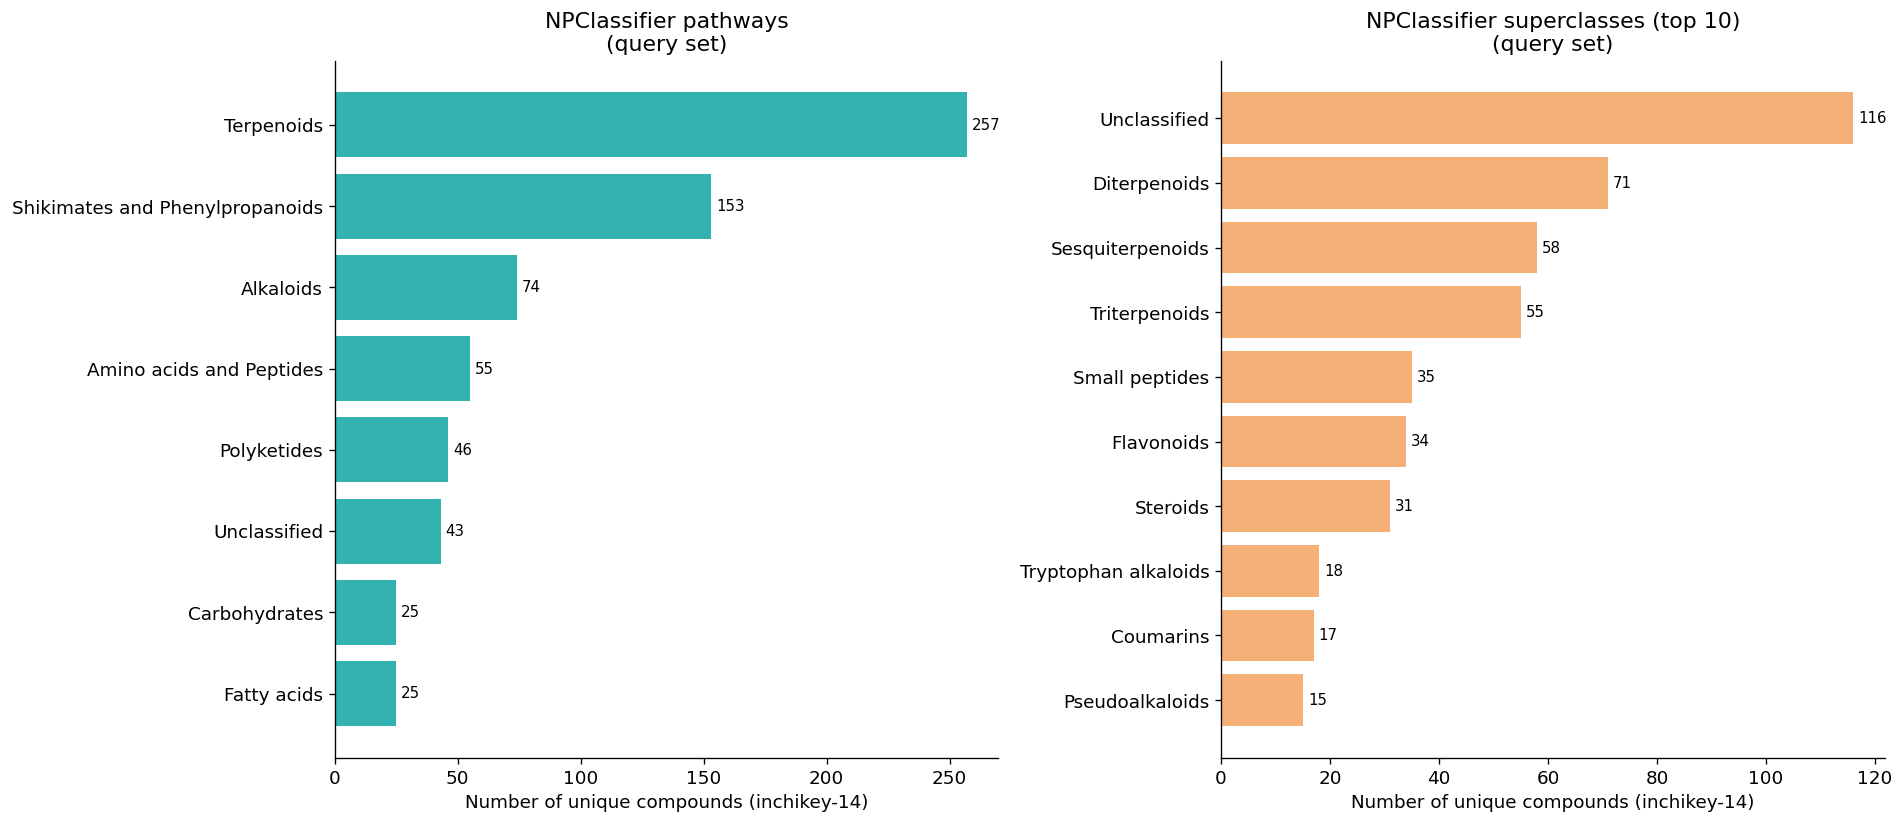

In [11]:
TOP_N_SC = 10  # number of superclasses to display

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Left: pathways ─────────────────────────────────────────────────────────
ax = axes[0]
bars = ax.barh(
    pathway_counts.index,
    pathway_counts.values,
    color=LIBRARY_PALETTE["Query"],
    edgecolor="none",
    alpha=0.85,
)
ax.set_xlabel("Number of unique compounds (inchikey-14)")
ax.set_title("NPClassifier pathways\n(query set)")
ax.bar_label(bars, padding=3, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

# ── Right: top superclasses ────────────────────────────────────────────────
ax = axes[1]
top_sc = superclass_counts.tail(TOP_N_SC)
bars = ax.barh(
    top_sc.index,
    top_sc.values,
    color=LIBRARY_PALETTE["Other"],
    edgecolor="none",
    alpha=0.85,
)
ax.set_xlabel("Number of unique compounds (inchikey-14)")
ax.set_title(f"NPClassifier superclasses (top {TOP_N_SC})\n(query set)")
ax.bar_label(bars, padding=3, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}/npclassifier_distribution.png", dpi=400, bbox_inches="tight")
plt.show()